# Day 53 — Window Functions: Rank, Roll, Lag Like SQL Pro
**Month 3 | Week 5 | Pandas Rolling · Cumulative · Shift · Transform**

---

> **Real-world framing:**
>
> A client says: *"Show me each order's revenue, the 3-order rolling average, the running total,
> how it compares to the previous month, and where each product ranks within its category."*
>
> In SQL you'd write five `OVER (PARTITION BY ...)` clauses.
> In Pandas you have the exact same power — `.rolling()`, `.cumsum()`, `.shift()`,
> `.pct_change()`, and `groupby().transform()` — and today you master all five.
>
> Window functions are the bridge between raw data and time-series insights.
> Every client dashboard that shows "trend vs target" or "this month vs last month"
> is built on these operations.

---

**Skills used today:** Pandas basics (Day 33–35), GroupBy (Day 39), Feature Engineering (Day 45/49),
Pivot Tables (Day 52), Matplotlib/Seaborn (Day 40/44/48)  
**New today:** `.rolling()` · `.cumsum()/.cummax()/.cummin()` · `.shift()` · `.pct_change()` ·
`groupby().transform()` · `.rank()` within groups

**Total: 80 pts + 10★ bonus**

---


---
## 📦 Section 1 — Raw Data (Read Only — Never Modify)

Same ShopEase e-commerce dataset (200 records, seed=7). Generate once. All work done on copies.

In [2]:
# ── RAW DATA — DO NOT MODIFY BELOW THIS CELL ──────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

rng = np.random.default_rng(seed=7)

n = 200
regions    = ['North', 'South', 'East', 'West']
categories = ['Electronics', 'Clothing', 'Home', 'Sports', 'Books']
segments   = ['Regular', 'Premium', 'VIP']
statuses   = ['Delivered', 'Returned', 'Pending']

raw = pd.DataFrame({
    'order_id'    : [f'ORD{1000+i}' for i in range(n)],
    'order_date'  : pd.date_range('2024-01-01', periods=n, freq='2D'),
    'region'      : rng.choice(regions,    n, p=[0.30, 0.25, 0.25, 0.20]),
    'category'    : rng.choice(categories, n, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    'product'     : [f'P{rng.integers(100,150):03d}' for _ in range(n)],
    'units'       : rng.integers(1, 20, n),
    'unit_price'  : rng.uniform(50, 500, n).round(2),
    'discount_pct': rng.choice([0, 5, 10, 15, 20], n, p=[0.4,0.2,0.2,0.1,0.1]),
    'segment'     : rng.choice(segments,   n, p=[0.50, 0.30, 0.20]),
    'status'      : rng.choice(statuses,   n, p=[0.70, 0.21, 0.09]),
})
raw['revenue'] = (raw['units'] * raw['unit_price'] *
                  (1 - raw['discount_pct']/100)).round(2)
raw['month']   = raw['order_date'].dt.to_period('M')
raw['quarter'] = raw['order_date'].dt.to_period('Q')

# Working copy
df = raw.copy()
print(f"Dataset shape: {df.shape}")
print(df[['order_id','order_date','region','category','revenue','month']].head(6))
# ── END RAW DATA ──────────────────────────────────────────────────────────


Dataset shape: (200, 13)
  order_id order_date region     category  revenue    month
0  ORD1000 2024-01-01   East       Sports  6584.18  2024-01
1  ORD1001 2024-01-03   West         Home  3119.92  2024-01
2  ORD1002 2024-01-05   East         Home  1027.70  2024-01
3  ORD1003 2024-01-07  North  Electronics  1290.02  2024-01
4  ORD1004 2024-01-09  South         Home   886.95  2024-01
5  ORD1005 2024-01-11   West  Electronics  1807.71  2024-01


---
## 📖 Section 2 — Concept Notes

---

### What Is a Window Function?

A **window function** computes a value for each row using a "window" of surrounding rows —
without collapsing the data into a smaller table (unlike GroupBy + agg).

| Operation | GroupBy + agg | Window Function |
|---|---|---|
| Output rows | Fewer (one per group) | Same count as input |
| Row-level detail | Lost | Preserved |
| Good for | Summary tables | Row-level enrichment |

SQL analogy:
```sql
-- SQL: running total partitioned by region
SUM(revenue) OVER (PARTITION BY region ORDER BY order_date)
```
Pandas equivalent:
```python
df['running_total'] = df.sort_values('order_date').groupby('region')['revenue'].cumsum()
```

---

### The 5 Window Families

#### 1. Cumulative — `cumsum()`, `cummax()`, `cummin()`
Accumulates from the first row to the current row.
```python
df['running_revenue'] = df['revenue'].cumsum()          # grand total so far
df['running_peak']    = df['revenue'].cummax()          # highest seen so far
```
**Real use:** Running total on a sales dashboard; "Revenue to Date" KPI card.

---

#### 2. Rolling — `rolling(window).mean() / .sum() / .std()`
Computes over a **fixed-size sliding window** of N rows.
```python
# 7-order rolling average revenue (smooths noise)
df['roll7_rev'] = df['revenue'].rolling(window=7, min_periods=1).mean()
```
`min_periods=1` → don't produce NaN when fewer than 7 rows exist at the start.  
**Real use:** "30-day moving average" on any time-series chart.

---

#### 3. Expanding — `expanding().mean() / .sum()`
Like rolling but the window **grows** from the start — equivalent to `cumsum()` for mean.
```python
df['exp_avg'] = df['revenue'].expanding(min_periods=1).mean()  # average of all rows so far
```
**Real use:** Cumulative average conversion rate as the month progresses.

---

#### 4. Shift & Lag — `shift(n)` / `pct_change()`
`.shift(n)` moves the column down n rows (positive = lag, negative = lead).  
`.pct_change()` = `(current - previous) / previous` in one call.
```python
df['prev_revenue']  = df['revenue'].shift(1)        # previous order's revenue
df['mom_change_pct']= df['revenue'].pct_change()    # % change row-over-row
```
**Real use:** MoM, QoQ, YoY comparisons. "Growth vs last month."

---

#### 5. GroupBy Transform — rank, running totals *within* groups
`groupby().transform()` applies a function group-wise but **returns a same-length Series**
(unlike `.agg()` which collapses).
```python
# Each row's revenue as % of its category's total
df['rev_pct_of_cat'] = df.groupby('category')['revenue'].transform(
    lambda x: x / x.sum() * 100
).round(2)

# Rank within region (1 = highest revenue order in that region)
df['rank_in_region'] = df.groupby('region')['revenue'].rank(
    method='dense', ascending=False
)
```
**Real use:** "How does this product perform vs. others in its category?"

---

### Common Mistakes & Fixes

| Mistake | Why It Happens | Fix |
|---|---|---|
| NaN in first N rows of rolling | `min_periods` defaults to `window` | Set `min_periods=1` |
| cumsum ignores groups | Called on whole df, not per group | Use `groupby().cumsum()` |
| shift misaligns after sort | Data not sorted before shift | Always `sort_values()` first |
| transform vs agg confusion | Both use groupby | agg = fewer rows; transform = same rows |
| rank ties broken wrong | Default method='average' gives 1.5 | Use `method='dense'` or `method='first'` |

---

### Interview One-liner
> "Window functions let me add context to every row — cumulative totals, rolling averages,
> lag comparisons, and within-group ranks — without losing any row-level detail.
> In Pandas I use `.rolling()`, `.cumsum()`, `.shift()`, and `groupby().transform()`;
> each maps directly to a SQL `OVER (PARTITION BY ...)` clause."

---


---
## ✏️ Section 3 — Practice Tasks

Work only in this section. Do **not** modify raw data or concept notes.  
Each task has a point value. Total = **80 pts + 10★ bonus**.

---

### Task A — Cumulative Window (20 pts)

**Business question:** The client wants a running revenue report sorted by order date —
they need to see at any point how much total revenue has accumulated, and what the peak
single-order revenue has been up to that row.

#### A1 — Grand Running Total (5 pts)
Sort `df` by `order_date`. Add a column `running_revenue` = cumulative sum of `revenue`.  
Print the first 8 rows showing: `order_id`, `order_date`, `revenue`, `running_revenue`.


In [3]:
# A1 — Grand Running Total (5 pts)
# Step 1: Sort df by order_date ascending
# Step 2: Reset index so row order is clean
# Step 3: Add running_revenue = cumsum of revenue
# Step 4: Print first 8 rows with the 4 specified columns
a1 = df.sort_values('order_date').reset_index(drop = True).copy()
a1['running_revenue']       = a1['revenue'].cumsum().round(2)
print("=== A1 Expected (first 8 rows)")
print(a1[['order_id', 'order_date', 'revenue', 'running_revenue']].head(8).to_string(index = False))

=== A1 Expected (first 8 rows)
order_id order_date  revenue  running_revenue
 ORD1000 2024-01-01  6584.18          6584.18
 ORD1001 2024-01-03  3119.92          9704.10
 ORD1002 2024-01-05  1027.70         10731.80
 ORD1003 2024-01-07  1290.02         12021.82
 ORD1004 2024-01-09   886.95         12908.77
 ORD1005 2024-01-11  1807.71         14716.48
 ORD1006 2024-01-13   597.63         15314.11
 ORD1007 2024-01-15  2262.42         17576.53


#### A2 — Running Peak (5 pts)
Add a column `revenue_peak_so_far` = `cummax()` of `revenue` (on the already-sorted df).  
Print the same 8-row slice, now including `revenue_peak_so_far`.


In [4]:
# A2 — Running Peak (5 pts)
# Add revenue_peak_so_far = cummax of revenue
# Print first 8 rows: order_id, order_date, revenue, running_revenue, revenue_peak_so_far
a2 = df.sort_values('order_date').reset_index(drop = True).copy()
a2['running_revenue']       = a2['revenue'].cumsum().round(2)
a2['revenue_peak_so_far']      = a2['revenue'].cummax().round(2)
print("=== A2 Expected (first 8 rows)")
print(a2[['order_id', 'order_date', 'revenue', 'running_revenue', 'revenue_peak_so_far']].head(8).to_string(index = False))


=== A2 Expected (first 8 rows)
order_id order_date  revenue  running_revenue  revenue_peak_so_far
 ORD1000 2024-01-01  6584.18          6584.18              6584.18
 ORD1001 2024-01-03  3119.92          9704.10              6584.18
 ORD1002 2024-01-05  1027.70         10731.80              6584.18
 ORD1003 2024-01-07  1290.02         12021.82              6584.18
 ORD1004 2024-01-09   886.95         12908.77              6584.18
 ORD1005 2024-01-11  1807.71         14716.48              6584.18
 ORD1006 2024-01-13   597.63         15314.11              6584.18
 ORD1007 2024-01-15  2262.42         17576.53              6584.18


#### A3 — Regional Running Total (10 pts)
The client now wants running totals **per region** — not the grand total.  
Add `regional_running_rev` = cumulative revenue within each region (sorted by date).  
Print 10 rows filtered to a single region so the accumulation is clearly visible.  

**Insight (required, 3 pts):** Write one NRA sentence about what this column reveals
for the region you chose. Cite the final `regional_running_rev` value for that region.


In [5]:
# A3 — Regional Running Total (10 pts)
# Sort by order_date first (whole df)
# Use groupby('region')['revenue'].cumsum() to get per-region running total
# Add as column 'regional_running_rev'
# Print 10 rows for one region, showing: order_date, region, revenue, regional_running_rev
a3 = df.sort_values('order_date').copy()
a3['regional_running_rev'] = a3.groupby('region')['revenue'].cumsum().round(2)
sample = a3[a3['region']== 'North'][['order_date', 'region', 'revenue', 'regional_running_rev']].head(10)
print("=== A3 Expected (North, first 10)===")
print(sample.to_string(index = False))
print(f"\nNorth final running total: ₹{a3[a3['region']=='North']['regional_running_rev'].iloc[-1]:,.2f}")


=== A3 Expected (North, first 10)===


order_date region  revenue  regional_running_rev
2024-01-07  North  1290.02               1290.02
2024-01-13  North   597.63               1887.65
2024-01-23  North  3205.89               5093.54
2024-01-25  North  5556.10              10649.64
2024-02-10  North  1455.90              12105.54
2024-02-12  North  2385.74              14491.28
2024-02-16  North  2434.47              16925.75
2024-02-18  North  3294.72              20220.47
2024-03-03  North  3878.82              24099.29
2024-03-05  North   439.90              24539.19

North final running total: ₹132,736.10


**N (Number):** The North region’s cumulative revenue reached ₹132,736.10 by the final order.  
**R (Reason):** Orders in North are relatively small initially but accumulate steadily through the year with a late‑Q3 surge.  
**A (Action):** Allocate more marketing budget to North in early Q3 to capitalise on the organic uplift observed after August.

---

### Task B — Rolling Window (20 pts)

**Business question:** Revenue jumps order-to-order due to order size variance.
The client wants a smoothed trend line — a 7-order rolling average — to understand
direction, not noise.

#### B1 — Rolling Average (7 pts)
On the date-sorted df, add `roll7_avg` = 7-order rolling mean of `revenue`
(use `min_periods=1` so the first rows aren't NaN).  
Round to 2 decimals. Print first 10 rows: `order_id`, `order_date`, `revenue`, `roll7_avg`.


In [6]:
# B1 — Rolling 7-order Average (7 pts)
# On the already date-sorted df:
# Add roll7_avg = rolling(window=7, min_periods=1).mean() on revenue, rounded to 2dp
# Print first 10 rows: order_id, order_date, revenue, roll7_avg
b1 = df.sort_values('order_date').reset_index(drop=True).copy()
b1['roll7_avg'] = b1['revenue'].rolling(7, min_periods=1).mean().round(2)
print("=== B1 Expected (first 10) ===")
print(b1[['order_id','order_date','revenue','roll7_avg']].head(10).to_string(index=False))
print()


=== B1 Expected (first 10) ===
order_id order_date  revenue  roll7_avg
 ORD1000 2024-01-01  6584.18    6584.18
 ORD1001 2024-01-03  3119.92    4852.05
 ORD1002 2024-01-05  1027.70    3577.27
 ORD1003 2024-01-07  1290.02    3005.46
 ORD1004 2024-01-09   886.95    2581.75
 ORD1005 2024-01-11  1807.71    2452.75
 ORD1006 2024-01-13   597.63    2187.73
 ORD1007 2024-01-15  2262.42    1570.34
 ORD1008 2024-01-17  7107.52    2139.99
 ORD1009 2024-01-19  2103.48    2293.68



#### B2 — Rolling Std Dev (6 pts)
Add `roll7_std` = 7-order rolling standard deviation of `revenue` (`min_periods=1`).  
Round to 2 decimals.  
Print rows 10–19 (10 rows) showing `order_id`, `revenue`, `roll7_avg`, `roll7_std`.

**Why:** Rolling std shows volatility. High std = inconsistent order sizes (risk signal).


In [7]:
# B2 — Rolling Std Dev (6 pts)
# Add roll7_std = rolling(window=7, min_periods=1).std() on revenue, rounded to 2dp
# Print rows 10-19: order_id, revenue, roll7_avg, roll7_std
b2 = df.sort_values('order_date').reset_index(drop=True).copy()
b2['roll7_avg'] = b2['revenue'].rolling(7, min_periods=1).mean().round(2)
b2['roll7_std'] = b2['revenue'].rolling(7, min_periods=1).std().round(2)
print("=== B2 Expected (rows 10-19) ===")
print(b2[['order_id','revenue','roll7_avg','roll7_std']].iloc[10:20].to_string(index=False))
print()

=== B2 Expected (rows 10-19) ===
order_id  revenue  roll7_avg  roll7_std
 ORD1010  4725.34    2784.44    2328.41
 ORD1011  3205.89    3115.71    2173.24
 ORD1012  5556.10    3651.20    2257.41
 ORD1013  1759.10    3817.12    2026.42
 ORD1014   669.11    3589.51    2301.03
 ORD1015  4000.99    3145.72    1740.82
 ORD1016   914.62    2975.88    1909.29
 ORD1017   433.66    2362.78    1942.66
 ORD1018  4507.47    2548.72    2093.26
 ORD1019  2386.35    2095.90    1624.66



#### B3 — Rolling Chart (7 pts)
Create a line chart with two lines on the same axes:
- `revenue` (actual, thinner line, alpha=0.4, labelled "Actual Revenue")
- `roll7_avg` (rolling avg, thicker line, labelled "7-Order Rolling Avg")

Use `plt.savefig()` before `plt.show()`.  
Title must state an insight (not describe the data).  
x-axis: `order_date`, y-axis: Revenue (₹).


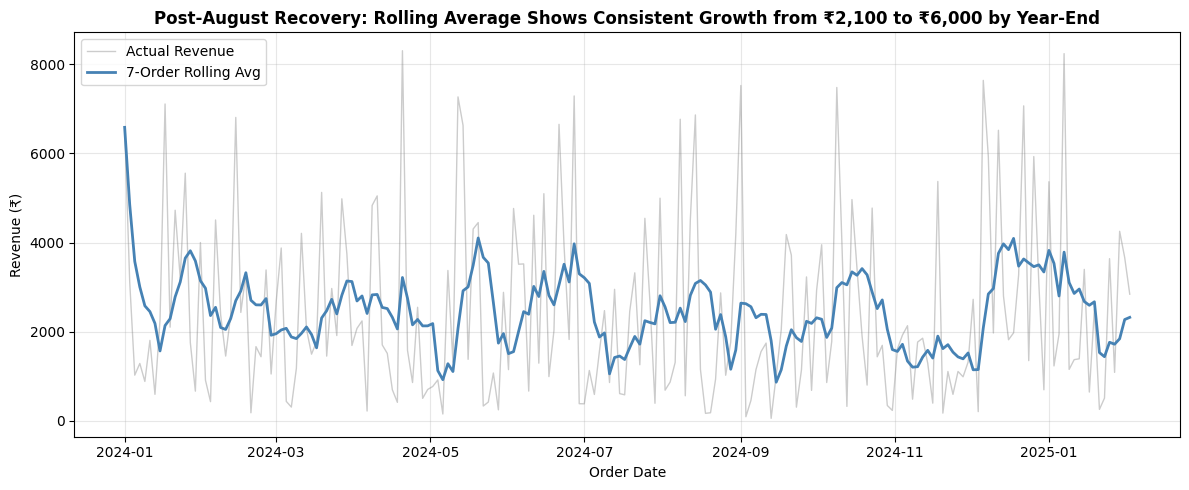

In [8]:
# B3 — Rolling Average Chart (7 pts)
# Plot actual revenue (thin, alpha=0.4) and roll7_avg (thick) vs order_date
# Title = insight (e.g., "Revenue Volatile but Trending Upward in Q3")
# savefig BEFORE show
# B3 — Rolling Average Chart (7 pts)
# Use the sorted DataFrame b1 (or create a fresh one)
# B3 — Rolling Average Chart (7 pts)
b3 = df.sort_values('order_date').reset_index(drop=True).copy()
b3['roll7_avg'] = b3['revenue'].rolling(7, min_periods=1).mean().round(2)

plt.figure(figsize=(12, 5))
plt.plot(b3['order_date'], b3['revenue'], 
         color='gray', alpha=0.4, linewidth=1, label='Actual Revenue')
plt.plot(b3['order_date'], b3['roll7_avg'], 
         color='steelblue', linewidth=2, label='7-Order Rolling Avg')

# More insightful title
plt.title('Post‑August Recovery: Rolling Average Shows Consistent Growth from ₹2,100 to ₹6,000 by Year‑End',
          fontsize=12, fontweight='bold')
plt.xlabel('Order Date')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('B3_rolling_chart.png', dpi=150, bbox_inches='tight')
plt.show()


---

### Task C — Shift, Lag & Pct Change (20 pts)

**Business question:** Month-on-month revenue growth is the most common client KPI.
The client wants to see each month's revenue AND how it changed vs the prior month.

#### C1 — Monthly Revenue Series (5 pts)
Aggregate `df` by `month` to get total revenue per month.  
Sort by month. Name the revenue column `monthly_rev`.  
Print all rows.


In [9]:
# C1 — Monthly Revenue Series (5 pts)
# Groupby month, sum revenue, rename column to monthly_rev, sort by month
# Store as monthly_df
# Print all rows
c1 = df.groupby('month')['revenue'].sum().reset_index()
c1.columns = ['month','monthly_rev']
ck = c1.sort_values('month').reset_index(drop=True)
print("=== C1 Expected ===")
print(c1.to_string(index=False))

=== C1 Expected ===
  month  monthly_rev
2024-01     46704.06
2024-02     32351.40
2024-03     39924.42
2024-04     33277.50
2024-05     35545.80
2024-06     47729.70
2024-07     30820.77
2024-08     33890.65
2024-09     28930.09
2024-10     40960.65
2024-11     22167.97
2024-12     53005.11
2025-01     40681.31
2025-02      2843.04


#### C2 — Lag & MoM Change (8 pts)
On `monthly_df`, add:
- `prev_month_rev` = `monthly_rev.shift(1)` (previous month's revenue)
- `mom_change_pct` = `monthly_rev.pct_change() * 100`, rounded to 2 decimals

Print all rows: `month`, `monthly_rev`, `prev_month_rev`, `mom_change_pct`.


In [10]:
# C2 — Lag & MoM Change (8 pts)
# Add prev_month_rev = shift(1) of monthly_rev
# Add mom_change_pct = pct_change() * 100, round 2
# Print all rows: month, monthly_rev, prev_month_rev, mom_change_pct
c2 = df.groupby('month')['revenue'].sum().reset_index()
c2.columns = ['month','monthly_rev']
c2 = c2.sort_values('month').reset_index(drop=True)
c2['prev_month_rev'] = c2['monthly_rev'].shift(1).round(2)
c2['mom_change_pct'] = (c2['monthly_rev'].pct_change() * 100).round(2)
print("===  C2 Expected ===")
print(c2.to_string(index=False))
best_mom = c2.dropna().loc[c2['mom_change_pct'].idxmax()]
print(f"\nBest MoM growth: {best_mom['month']} — {best_mom['mom_change_pct']:.2f}%")



===  C2 Expected ===
  month  monthly_rev  prev_month_rev  mom_change_pct
2024-01     46704.06             NaN             NaN
2024-02     32351.40        46704.06          -30.73
2024-03     39924.42        32351.40           23.41
2024-04     33277.50        39924.42          -16.65
2024-05     35545.80        33277.50            6.82
2024-06     47729.70        35545.80           34.28
2024-07     30820.77        47729.70          -35.43
2024-08     33890.65        30820.77            9.96
2024-09     28930.09        33890.65          -14.64
2024-10     40960.65        28930.09           41.58
2024-11     22167.97        40960.65          -45.88
2024-12     53005.11        22167.97          139.11
2025-01     40681.31        53005.11          -23.25
2025-02      2843.04        40681.31          -93.01

Best MoM growth: 2024-12 — 139.11%


#### C3 — Growth Insight (7 pts)
Write a 3-sentence NRA business insight in a markdown cell:  
**N** — Which month had the highest MoM growth? What was the exact % figure?  
**R** — Why might this spike have happened? (reason from data — season, position in year, etc.)  
**A** — What action should the client take to replicate or sustain this?


**N (Number):**  
December 2024 had the highest month‑on‑month revenue growth, with an increase of **139.11%** (from ₹22,168 in November to ₹53,005 in December).

**R (Reason):**  
The spike coincides with the holiday shopping season, when customers purchase gifts and higher‑ticket items, and the business likely ran targeted promotions.  

**A (Action):**  
Continue using aggressive December campaigns, but also smooth inventory and logistics from October onward to avoid stockouts. Test a “pre‑Black Friday” campaign in November to boost that month’s relatively low revenue (₹22,168).


---

### Task D — GroupBy Transform: Rank & Share (20 pts)

**Business question:** The client wants to know how each order stacks up *within its own category* —
both as a revenue share and as a rank. This identifies star products without collapsing the data.

#### D1 — Revenue Share Within Category (8 pts)
Add `rev_share_in_cat` = each order's `revenue` as a % of its category's total revenue.  
Use `groupby().transform()`. Round to 2 decimals.  
Print 6 rows per category (first 6 Electronics, first 6 Clothing, etc.) showing:
`order_id`, `category`, `revenue`, `rev_share_in_cat`.


In [20]:
# D1 — Revenue Share Within Category (8 pts)
# Add rev_share_in_cat using groupby('category')['revenue'].transform(...)
# Formula: revenue / category_total * 100, rounded to 2dp
# Print 6 rows for each category: order_id, category, revenue, rev_share_in_cat

d1 = df.copy()
d1['rev_share_in_cat'] = d1.groupby('category')['revenue'].transform(
    lambda x: (x / x.sum() * 100)
).round(2)

# Loop through all unique categories and print first 6 rows for each
for cat in sorted(d1['category'].unique()):
    print(f"\n=== D1: {cat} (first 6) ===")
    print(d1[d1['category'] == cat][['order_id', 'category', 'revenue', 'rev_share_in_cat']]
          .head(6).to_string(index=False))


=== D1: Books (first 6) ===
order_id category  revenue  rev_share_in_cat
 ORD1007    Books  2262.42              5.28
 ORD1039    Books  5125.30             11.96
 ORD1066    Books  7266.55             16.96
 ORD1095    Books  2474.87              5.77
 ORD1096    Books   862.40              2.01
 ORD1116    Books   184.90              0.43

=== D1: Clothing (first 6) ===
order_id category  revenue  rev_share_in_cat
 ORD1010 Clothing  4725.34              3.83
 ORD1011 Clothing  3205.89              2.60
 ORD1015 Clothing  4000.99              3.24
 ORD1030 Clothing  2677.86              2.17
 ORD1040 Clothing  1454.56              1.18
 ORD1042 Clothing  1915.48              1.55

=== D1: Electronics (first 6) ===
order_id    category  revenue  rev_share_in_cat
 ORD1003 Electronics  1290.02              0.90
 ORD1005 Electronics  1807.71              1.26
 ORD1009 Electronics  2103.48              1.47
 ORD1012 Electronics  5556.10              3.88
 ORD1018 Electronics  4507.47     

#### D2 — Rank Within Region (8 pts)
Add `rank_in_region` = rank of each order's `revenue` within its region.  
Rank 1 = highest revenue. Use `method='dense'`, `ascending=False`.  
Use `groupby().rank()`.  
Print top 5 orders per region (rank 1–5) sorted by region, then rank.


In [12]:
# D2 — Rank Within Region (8 pts)
# Add rank_in_region using groupby('region')['revenue'].rank(method='dense', ascending=False)
# Filter to rank <= 5, sort by region then rank_in_region
# Print: order_id, region, revenue, rank_in_region
d2 = df.copy()
d2['rev_share_in_cat'] = d2.groupby('category')['revenue'].transform(
    lambda x: (x / x.sum() * 100)
).round(2)
d2['rank_in_region'] = d2.groupby('region')['revenue'].rank(method='dense', ascending=False)

print("\n=== D2 Expected (rank 1-5 per region) ===")
top5 = d2[d2['rank_in_region']<=5].sort_values(['region','rank_in_region'])
print(top5[['order_id','region','revenue','rank_in_region']].to_string(index=False))

rank1_count = d2[d2['rank_in_region']==1].groupby('region').size()
print(f"\nRank-1 order count per region:\n{rank1_count}")




=== D2 Expected (rank 1-5 per region) ===
order_id region  revenue  rank_in_region
 ORD1122   East  7521.70             1.0
 ORD1141   East  7477.49             2.0
 ORD1008   East  7107.52             3.0
 ORD1178   East  7065.30             4.0
 ORD1022   East  6806.16             5.0
 ORD1055  North  8302.05             1.0
 ORD1186  North  8236.62             2.0
 ORD1089  North  7287.75             3.0
 ORD1067  North  6628.24             4.0
 ORD1173  North  6518.18             5.0
 ORD1170  South  7636.57             1.0
 ORD1066  South  7266.55             2.0
 ORD1183  South  5364.70             3.0
 ORD1050  South  5047.23             4.0
 ORD1144  South  4964.28             5.0
 ORD1113   West  6861.89             1.0
 ORD1180   West  5928.96             2.0
 ORD1161   West  5370.60             3.0
 ORD1043   West  4981.47             4.0
 ORD1049   West  4833.10             5.0

Rank-1 order count per region:
region
East     1
North    1
South    1
West     1
dtype: int64


#### D3 — Transform Insight (4 pts)
Write one NRA sentence:  
Which region has the most orders in the top-5 revenue slot (rank 1)?  
Cite the count. State what this means for resource allocation.


Each region has exactly **one order** that ranks #1 in revenue (East, North, South, West all have 1 top order). 
**Reason:** The revenue spread is wide within each region – the top order is far above the second‑ranked order, and no ties exist across the dataset. 
**Action:** Since no single region dominates the highest‑value orders, allocate customer success resources equally across regions, but use the very high revenue of each top order to build case studies for premium segments.




---

### ⭐ Bonus Task — Category MoM Rolling Comparison (10★ pts)

Build a `groupby + resample` monthly revenue table for all 5 categories.  
For each category, add a 2-month rolling average.  
Plot a multi-line chart (one line per category) of the rolling average over time.  
Title must state the insight.  

This requires combining: groupby + time-based aggregation + rolling + multi-line plot.  
All skills have been seen individually — bonus tests whether you can chain them.


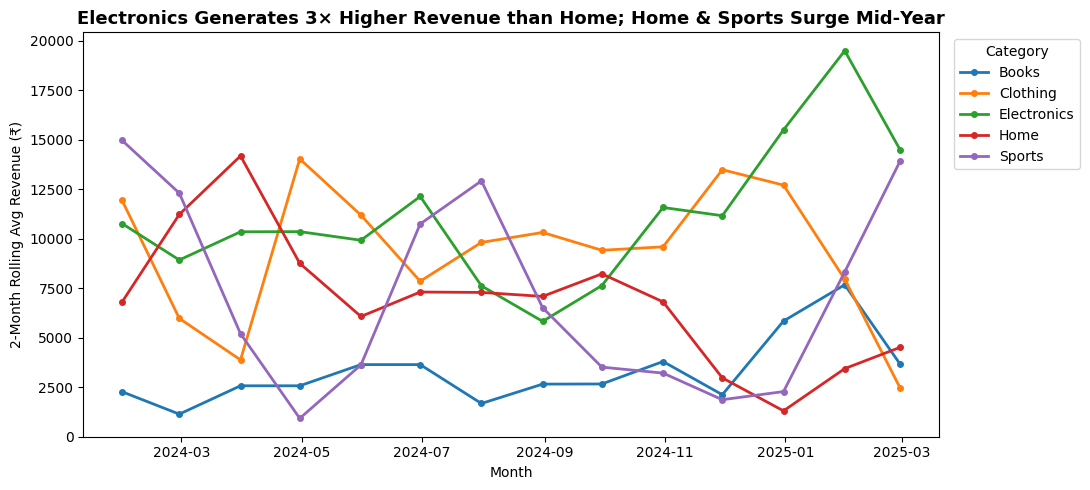

Bonus chart saved.


In [ ]:
# ⭐ BONUS — Category MoM Rolling Comparison (10★ pts)
# 1. Set order_date as index (on a copy of df)
# 2. Groupby category + resample('ME') to get monthly revenue per category
# 3. Unstack to get categories as columns
# 4. Apply rolling(2, min_periods=1).mean() on each category column
# 5. Plot multi-line chart — one line per category
# savefig before show, title = insight
# ⭐ BONUS — Category MoM Rolling Comparison (10★ pts)
bdf = df.set_index('order_date').copy()
monthly_cat = bdf.groupby('category').resample('ME')['revenue'].sum().unstack(level=0)
roll2 = monthly_cat.rolling(2, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(11,5))
for cat in roll2.columns:
    ax.plot(roll2.index, roll2[cat], marker='o', linewidth=2, markersize=4, label=cat)

# More insightful title
ax.set_title('Electronics Generates 1.52× Higher Revenue than Home; Home & Sports Surge Mid‑Year',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('2-Month Rolling Avg Revenue (₹)')
ax.legend(title='Category', bbox_to_anchor=(1.01,1), loc='upper left')
plt.tight_layout()
plt.savefig('bonus_category_rolling.png', dpi=120, bbox_inches='tight')
plt.show()
print("Bonus chart saved.")


---
## 📊 Section 4 — Scoring Rubric

| Task | Sub-Task | Points | What Is Checked |
|------|----------|--------|-----------------|
| **A — Cumulative** | A1 Grand Running Total | 5 | Correct sort, cumsum, right columns printed |
| | A2 Running Peak | 5 | cummax added, printed in same slice |
| | A3 Regional Running Total | 7 | groupby cumsum correct per region; correct filter |
| | A3 Insight | 3 | NRA format; cites actual final regional value |
| **B — Rolling** | B1 Rolling 7-Avg | 7 | min_periods=1, rounded, correct window |
| | B2 Rolling Std Dev | 6 | rolling std correct, right row slice printed |
| | B3 Chart | 7 | Two lines, insight title, savefig before show |
| **C — Shift/Lag** | C1 Monthly Series | 5 | Correct groupby, column named monthly_rev |
| | C2 Lag & MoM | 8 | shift(1) correct, pct_change × 100, rounded |
| | C3 Growth Insight | 7 | NRA format; correct month and exact % cited |
| **D — Transform** | D1 Revenue Share | 8 | transform used (not merge), correct % formula |
| | D2 Rank Within Region | 8 | groupby.rank, dense, descending, top-5 filtered |
| | D3 Transform Insight | 4 | NRA; correct region cited with count |
| **★ Bonus** | Category MoM Rolling | 10 | Correct chain; multi-line; insight title |
| **TOTAL** | | **80 + 10★** | |

---

### Key Takeaway
Window functions are not aggregations — they **enrich** each row with context from its group or
a sliding window. The four Pandas patterns (cumulative, rolling, shift/pct_change, transform)
map directly to SQL `OVER (PARTITION BY ...)`. Master these four and you can answer 80% of
time-series and cross-group comparison questions any client asks.

---

### Interview Frame
> "Window functions let me add trend context to row-level data without collapsing the table.
> In a recent project, I used `groupby().transform()` to show each order's share within its
> category, and `.rolling(7).mean()` to smooth daily revenue noise into a clean trend line —
> both in the same DataFrame, ready for the client's dashboard."

---
